# SAXS-TT IsoNet — Training Data Inspector

Visualises exactly what the model consumes during training, to verify the
canonical-frame missing-wedge logic + dual-source (fixed target) setup.

Volumes are pre-cropped to a sphere of diameter `cube_size = (min(X,Y,Z)//8)*8`
and spherically masked (exterior = 0 in normalised space). The GPU `VolumeAugmentor`:
- rotates the full `(cube_size, cube_size, cube_size)` volume by a random SO(3)
  (same rotation for v0 & v1); the sphere is rotation-invariant so corners stay near-zero,
- carves the **canonical** wedge of `k_wedge` from v0 → model input,
- target = rotated v1 (frozen round_00 in dual-source mode),
- `valid_missing` = carved-wedge ∩ source-measured-after-rotation.

Checks: (1) `|FFT(carved)|` dark exactly on the canonical wedge; (2) `valid_missing`
inside the carved wedge and outside the rotated source wedge; (3) numerical.

In [1]:
import sys, pathlib, tempfile
sys.path.insert(0, '/myhome/smartt')

import numpy as np
import torch
import matplotlib.pyplot as plt

from smartt.saxs_fbp import fibonacci_hemisphere
from smartt.saxs_isonet.wedge import goniometer_axis_for_half_space, missing_arc_length
from smartt.saxs_isonet.dataset import MissingWedgeSAXS, save_reconstruction_volumes, compute_norm_stats
from smartt.saxs_isonet.augment import VolumeAugmentor
from smartt.saxs_isonet.preprocess import spherical_crop, make_sphere_mask
from torch.utils.data import DataLoader
import lovely_tensors as lt
lt.monkey_patch()

# ── Parameters ────────────────────────────────────────────────────────────────
ISONET_DIR    = pathlib.Path('/myhome/data/smartt/shared/isonet_results/frogbone_gd')
ALPHA_DEG     = 45.0
HALF_SPACE    = 'y'
CUBE          = 64                  # sphere diameter / model input side (multiple of 8)
COND_DIM      = 64
MIN_WEDGE_DEG = 10.0
BATCH         = 6
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G_AXIS = goniometer_axis_for_half_space(HALF_SPACE)
print('device:', device, '| cube=%d' % CUBE)

# ── Load round_00 volumes + rsm_dirs, or synthesise a stand-in dataset ──────────
round0 = ISONET_DIR / 'round_00'
rsm_path = next((ISONET_DIR / n for n in ('rsm_dirs.npy', 'y_dirs.npy')
                 if (ISONET_DIR / n).exists()), None)

_tmp = None
if round0.exists() and rsm_path is not None and len(list(round0.glob('vol_*.npy'))) > 0:
    rsm_dirs = np.load(rsm_path)
    vol_dir = round0
    print(f'Loaded {len(rsm_dirs)} volumes from {vol_dir}')
else:
    print('[synthetic] frogbone round_00 not found — generating a stand-in dataset.')
    K = 12
    rng = np.random.RandomState(0)
    rsm_dirs = fibonacci_hemisphere(K, half_space=HALF_SPACE)
    vols = []
    for _ in range(K):
        v = rng.randn(65, 82, 65).astype(np.float32)
        vf = np.fft.fftn(v)
        kx = np.fft.fftfreq(v.shape[0]); ky = np.fft.fftfreq(v.shape[1]); kz = np.fft.fftfreq(v.shape[2])
        decay = np.exp(-(kx[:, None, None]**2 + ky[None, :, None]**2 + kz[None, None, :]**2) / 0.01)
        vols.append((np.fft.ifftn(vf * decay).real * (1 + 5*rng.rand())).astype(np.float32))
    vol_tensor = torch.from_numpy(np.stack(vols))
    cropped, _, CUBE = spherical_crop(vol_tensor, cube_size=CUBE)
    _tmp = tempfile.TemporaryDirectory(); vol_dir = pathlib.Path(_tmp.name)
    save_reconstruction_volumes(cropped, vol_dir)
    print(f'Synthetic volumes cropped to ({CUBE},{CUBE},{CUBE}) and saved to {vol_dir}')

K = len(rsm_dirs)
sphere_mask = make_sphere_mask(CUBE)
norm_stats = compute_norm_stats(vol_dir, mask=sphere_mask)   # interior-only stats from round_00
print(f'K={K}  alpha={ALPHA_DEG}  half_space={HALF_SPACE!r}  norm_stats={norm_stats.shape}')

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.
device: cuda | cube=64
Loaded 30 volumes from /myhome/data/smartt/shared/isonet_results/frogbone_gd/round_00
K=30  alpha=45.0  half_space='y'  norm_stats=(30, 2)


In [2]:
# Dual-source dataset (round 1: input == target == round_00) + GPU augmentor.
ds = MissingWedgeSAXS(vol_dir, rsm_dirs, ALPHA_DEG, goniometer_axis=G_AXIS,
                      cube_size=CUBE, n_samples=BATCH, min_wedge_deg=MIN_WEDGE_DEG,
                      target_dir=vol_dir, norm_stats=norm_stats)
loader = DataLoader(ds, batch_size=BATCH, drop_last=True, shuffle=True)
aug = VolumeAugmentor(rsm_dirs, ALPHA_DEG, goniometer_axis=G_AXIS,
                      cube_size=CUBE, conditioning_dim=COND_DIM, device=device)

v0, v1, k_src, k_wedge = next(iter(loader))
carved, target, cond, valid_missing = aug(v0, v1, k_src, k_wedge)
carved = carved.cpu(); target = target.cpu(); valid_missing = valid_missing.cpu()

print('v0/v1 (full volume) ', tuple(v0.shape))
print('carved/target       ', tuple(carved.shape))
print('cond                ', tuple(cond.shape))
print('valid_missing       ', tuple(valid_missing.shape), valid_missing.dtype)
print()
arcs = np.degrees([missing_arc_length(rsm_dirs[int(kw)], ALPHA_DEG, G_AXIS) for kw in k_wedge])
for s in range(BATCH):
    print(f'sample {s}: k_src={int(k_src[s]):2d}  k_wedge={int(k_wedge[s]):2d}  '
          f'missing_arc={arcs[s]:5.1f}°  valid_missing_voxels={int(valid_missing[s].sum())}')

INFO:Dataset: K=30, cube=64, dual_source=True, 21 carve dirs, 30 src dirs.
v0/v1 (full volume)  (6, 1, 64, 64, 64)
carved/target        (6, 1, 64, 64, 64)
cond                 (6, 1, 64)
valid_missing        (6, 64, 64, 64) torch.bool

sample 0: k_src=28  k_wedge= 1  missing_arc=179.7°  valid_missing_voxels=127040
sample 1: k_src=20  k_wedge=14  missing_arc=144.5°  valid_missing_voxels=71827
sample 2: k_src= 4  k_wedge= 7  missing_arc=172.4°  valid_missing_voxels=83458
sample 3: k_src=20  k_wedge=12  missing_arc=155.7°  valid_missing_voxels=87860
sample 4: k_src=28  k_wedge= 9  missing_arc=167.2°  valid_missing_voxels=116928
sample 5: k_src= 0  k_wedge= 6  missing_arc=174.4°  valid_missing_voxels=74528


## Real-space slices

`target` (rotated v1) vs `carved` (canonical wedge removed) vs difference.
The sphere boundary may appear as a thin dark ring at the volume edge — this is
intentional; it is rotation-invariant and the model sees it consistently.

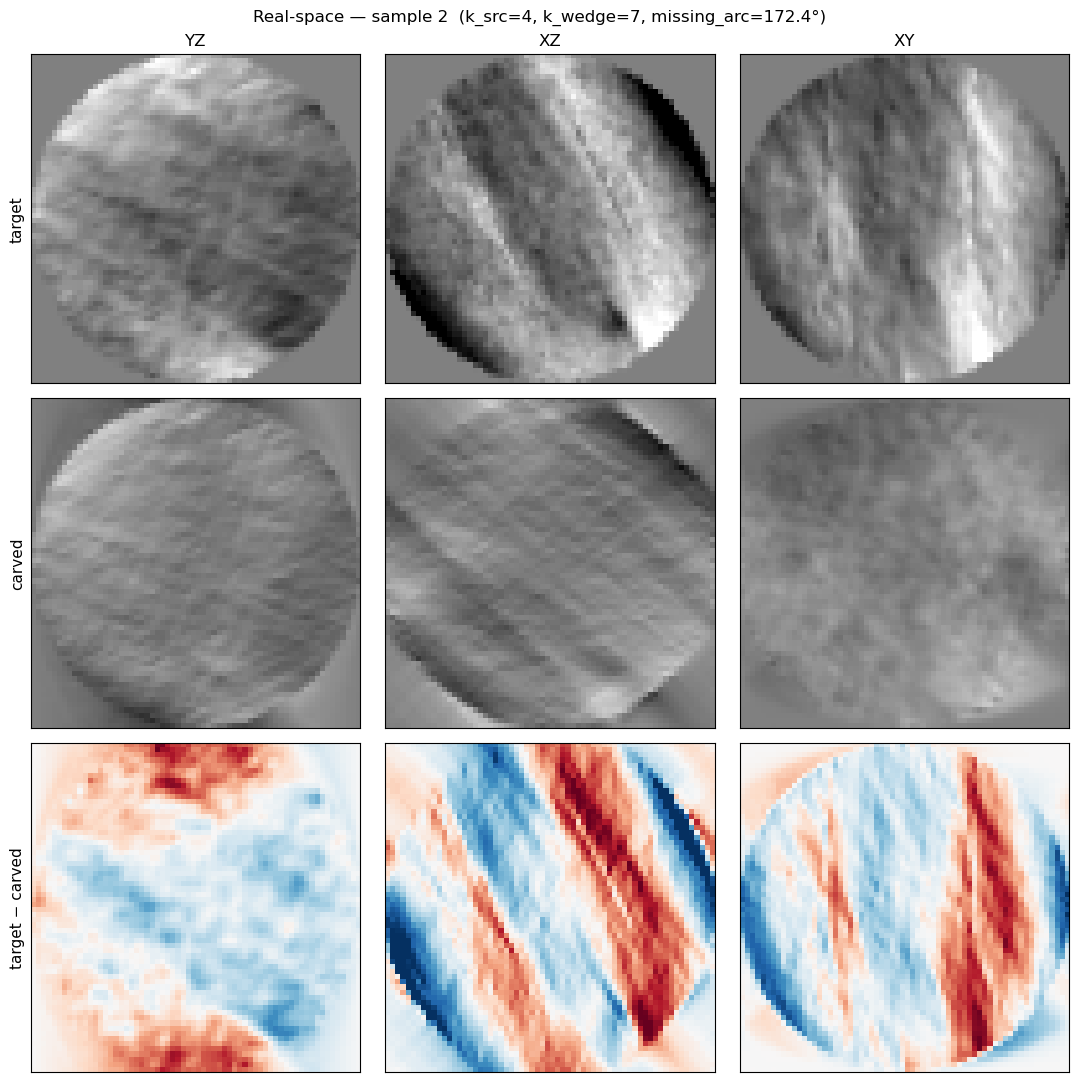

In [3]:
SAMPLE = 2   # change to inspect other samples

t = target[SAMPLE, 0].numpy(); c = carved[SAMPLE, 0].numpy(); d = t - c
mid = CUBE // 2
planes = [('YZ', lambda a: a[mid]), ('XZ', lambda a: a[:, mid]), ('XY', lambda a: a[:, :, mid])]

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
vlim = np.percentile(np.abs(t), 99) + 1e-9
for col, (name, sl) in enumerate(planes):
    axes[0, col].imshow(sl(t).T, origin='lower', cmap='gray', vmin=-vlim, vmax=vlim)
    axes[1, col].imshow(sl(c).T, origin='lower', cmap='gray', vmin=-vlim, vmax=vlim)
    dl = np.percentile(np.abs(d), 99) + 1e-9
    axes[2, col].imshow(sl(d).T, origin='lower', cmap='RdBu_r', vmin=-dl, vmax=dl)
    axes[0, col].set_title(name)
for r, lab in enumerate(['target', 'carved', 'target − carved']):
    axes[r, 0].set_ylabel(lab, fontsize=11)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Real-space — sample {SAMPLE}  (k_src={int(k_src[SAMPLE])}, '
             f'k_wedge={int(k_wedge[SAMPLE])}, missing_arc={arcs[SAMPLE]:.1f}°)', fontsize=12)
plt.tight_layout(); plt.show()

## Fourier-space alignment

Masks are fftshifted (DC centred); the canonical wedge lies in the xz-plane so the
**XZ** slice (y=centre) shows it best. `|FFT(carved)|` should be dark exactly where
the canonical keep-mask is purple, and `valid_missing` should sit inside it.

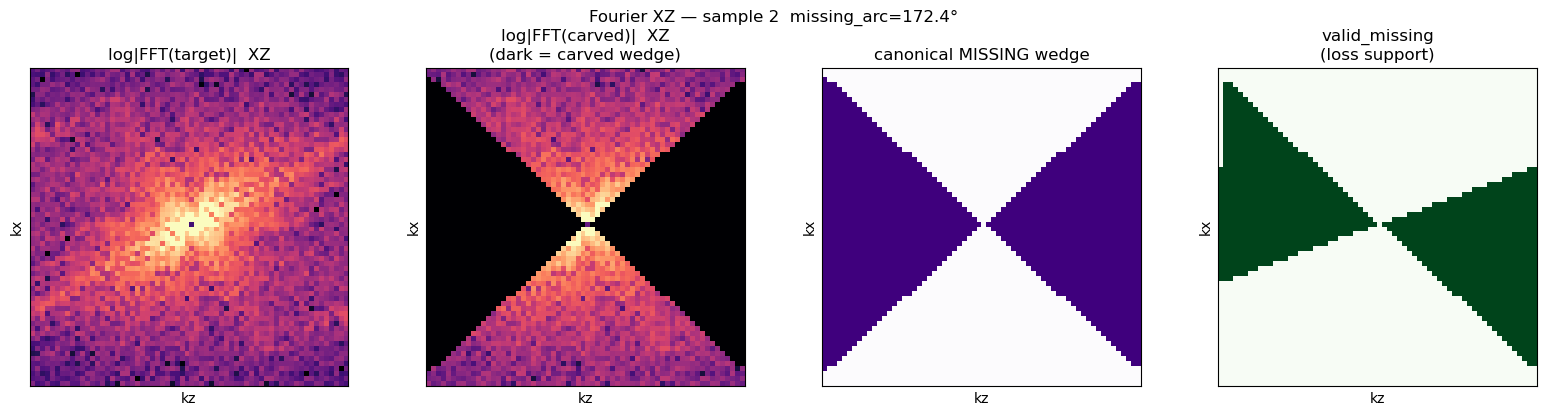

In [4]:
def xz(v): return v[:, CUBE // 2, :]
def log_fft_xz(v): return np.log1p(np.abs(xz(np.fft.fftshift(np.fft.fftn(v)))))

keep_canon = aug.canonical_keep[k_wedge.to(aug.device)].cpu().numpy()  # (B,C,C,C) shifted
vm = valid_missing.numpy()

ft_t = log_fft_xz(target[SAMPLE, 0].numpy()); ft_c = log_fft_xz(carved[SAMPLE, 0].numpy())
keep_xz = xz(keep_canon[SAMPLE]); vm_xz = xz(vm[SAMPLE])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
vmax = np.percentile(ft_t, 99) + 1e-9
axes[0].imshow(ft_t.T, origin='lower', cmap='magma', vmax=vmax); axes[0].set_title('log|FFT(target)|  XZ')
axes[1].imshow(ft_c.T, origin='lower', cmap='magma', vmax=vmax); axes[1].set_title('log|FFT(carved)|  XZ\n(dark = carved wedge)')
axes[2].imshow((~keep_xz).T, origin='lower', cmap='Purples'); axes[2].set_title('canonical MISSING wedge')
axes[3].imshow(vm_xz.T, origin='lower', cmap='Greens');        axes[3].set_title('valid_missing\n(loss support)')
for ax in axes: ax.set_xlabel('kz'); ax.set_ylabel('kx'); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Fourier XZ — sample {SAMPLE}  missing_arc={arcs[SAMPLE]:.1f}°', fontsize=12)
plt.tight_layout(); plt.show()

## Numerical verification (whole batch)

In [5]:
ok = True
for s in range(BATCH):
    keep = keep_canon[s].astype(bool); miss = ~keep; vms = vm[s].astype(bool)
    leak = int((vms & keep).sum())                                  # must be 0
    Fc = np.fft.fftshift(np.fft.fftn(carved[s, 0].numpy()))
    peak = np.abs(Fc).max()
    rel = (np.abs(Fc[miss]).max() / peak) if (miss.any() and peak > 0) else 0.0   # ~0
    nvm = int(vms.sum())                                            # > 0
    flag = '' if (leak == 0 and rel < 1e-5 and nvm > 0) else '  ←❌'
    if flag: ok = False
    print(f'sample {s}: leak={leak:5d}  rel.residual={rel:.2e}  valid_missing={nvm:6d}{flag}')
print()
print('ALL CHECKS PASSED ✅' if ok else 'SOME CHECKS FAILED ❌')

sample 0: leak=    0  rel.residual=2.23e-08  valid_missing=127040
sample 1: leak=    0  rel.residual=2.59e-08  valid_missing= 71827
sample 2: leak=    0  rel.residual=2.35e-08  valid_missing= 83458
sample 3: leak=    0  rel.residual=2.28e-08  valid_missing= 87860
sample 4: leak=    0  rel.residual=2.36e-08  valid_missing=116928
sample 5: leak=    0  rel.residual=1.07e-08  valid_missing= 74528

ALL CHECKS PASSED ✅


## Model fit test — does round_01 fill the wedge on training data?

Load the round_01 checkpoint and run the model on the **same batch used above**.
This is an in-sample test: if the model cannot fit the training data, the problem
is in training (loss / architecture / gradient); if it fits training but not new
volumes, it is a generalisation problem.

Three Fourier-space panels are compared in the canonical-wedge region (XZ slice):
- `log|FFT(target)|` — the correct answer the model should approach
- `log|FFT(carved)|` — what the model receives (wedge zeroed)
- `log|FFT(pred)|`   — what the model actually outputs

If training works, the wedge in `pred` should look brighter (more filled) than in
`carved`, and closer to `target`.  A `pred` that looks identical to `carved` means
the model is predicting zero in the missing region — not learning.

In [6]:
from smartt.saxs_isonet.train import build_model

# ── Point to the trained checkpoint ──────────────────────────────────────────
CKPT_PATH = ISONET_DIR / 'round_09' / 'checkpoint.pt'
# ─────────────────────────────────────────────────────────────────────────────

if not CKPT_PATH.exists():
    print(f'[SKIP] Checkpoint not found: {CKPT_PATH}')
    MODEL_AVAILABLE = False
else:
    ckpt = torch.load(CKPT_PATH, map_location=device)
    # Read architecture params from checkpoint; fall back to notebook defaults.
    cond_dim_ckpt = ckpt.get('conditioning_dim', COND_DIM)
    model = build_model(cross_attention_dim=cond_dim_ckpt).to(device)
    model.load_state_dict(ckpt['model'])
    model.eval()
    print(f'Loaded checkpoint: {CKPT_PATH}')
    print(f'  conditioning_dim={cond_dim_ckpt}  alpha={ckpt.get("alpha_deg","?")}°')
    MODEL_AVAILABLE = True

Loaded checkpoint: /myhome/data/smartt/shared/isonet_results/frogbone_gd/round_09/checkpoint.pt
  conditioning_dim=64  alpha=45.0°


In [11]:
if not MODEL_AVAILABLE:
    print('[SKIP]')
else:
    # Run the model on the batch (no canonical rotation needed — augmentor
    # already produced carved patches in the canonical frame for the cube).
    aug_dev = VolumeAugmentor(rsm_dirs, ALPHA_DEG, goniometer_axis=G_AXIS,
                              cube_size=CUBE, conditioning_dim=cond_dim_ckpt, device=device)

    # Re-draw the batch with a fixed seed so it's reproducible.
    # torch.manual_seed(42)
    # v0_t, v1_t, k_src_t, k_wedge_t = next(iter(DataLoader(ds, batch_size=BATCH, drop_last=True)))
    v0_t, v1_t, k_src_t, k_wedge_t = v0, v1, k_src, k_wedge
    with torch.no_grad():
        carved_t, target_t, cond_t, vm_t = aug_dev(v0_t, v1_t, k_src_t, k_wedge_t)
        timesteps = torch.zeros(BATCH, device=device, dtype=torch.long)
        pred_t = model(carved_t, timestep=timesteps, encoder_hidden_states=cond_t,
                       return_dict=False)[0]   # (B, 1, C, C, C)

        # Fourier inpainting: keep measured frequencies from carved, model fills wedge only.
        keep = aug_dev.canonical_keep[k_wedge_t.to(aug_dev.device)]  # (B,C,C,C) bool, shifted
        F_pred   = torch.fft.fftshift(torch.fft.fftn(pred_t.squeeze(1),   dim=(-3,-2,-1)), dim=(-3,-2,-1))
        F_carved = torch.fft.fftshift(torch.fft.fftn(carved_t.squeeze(1), dim=(-3,-2,-1)), dim=(-3,-2,-1))
        F_inpainted = torch.where(keep, F_carved, F_pred)
        pred_t = torch.fft.ifftn(
            torch.fft.ifftshift(F_inpainted, dim=(-3,-2,-1)), dim=(-3,-2,-1)).real.unsqueeze(1)

    carved_np = carved_t.cpu().squeeze(1).numpy()
    target_np = target_t.cpu().squeeze(1).numpy()
    pred_np   = pred_t.cpu().squeeze(1).numpy()

    arcs_t = np.degrees([missing_arc_length(rsm_dirs[int(kw)], ALPHA_DEG, G_AXIS)
                          for kw in k_wedge_t])
    print('Batch ready.  Sample arcs:', [f'{a:.1f}°' for a in arcs_t])

Batch ready.  Sample arcs: ['179.7°', '144.5°', '172.4°', '155.7°', '167.2°', '174.4°']


In [12]:
"pred_t", pred_t, "carved_t", carved_t, "target_t", target_t

('pred_t',
 tensor[6, 1, 64, 64, 64] n=1572864 (6 MiB) x∈[-4.656 | ▁▁▁▂█▃▁▁▁| 3.404] μ=5.445e-05 σ=0.650 cuda:0,
 'carved_t',
 tensor[6, 1, 64, 64, 64] n=1572864 (6 MiB) x∈[-3.427 |▁▁▁▁▃█▂▁▁▁| 3.016] μ=5.445e-05 σ=0.540 cuda:0,
 'target_t',
 tensor[6, 1, 64, 64, 64] n=1572864 (6 MiB) x∈[-5.332 | ▁▁▁▂█▃▂▁▁| 3.580] μ=5.445e-05 σ=0.681 cuda:0)

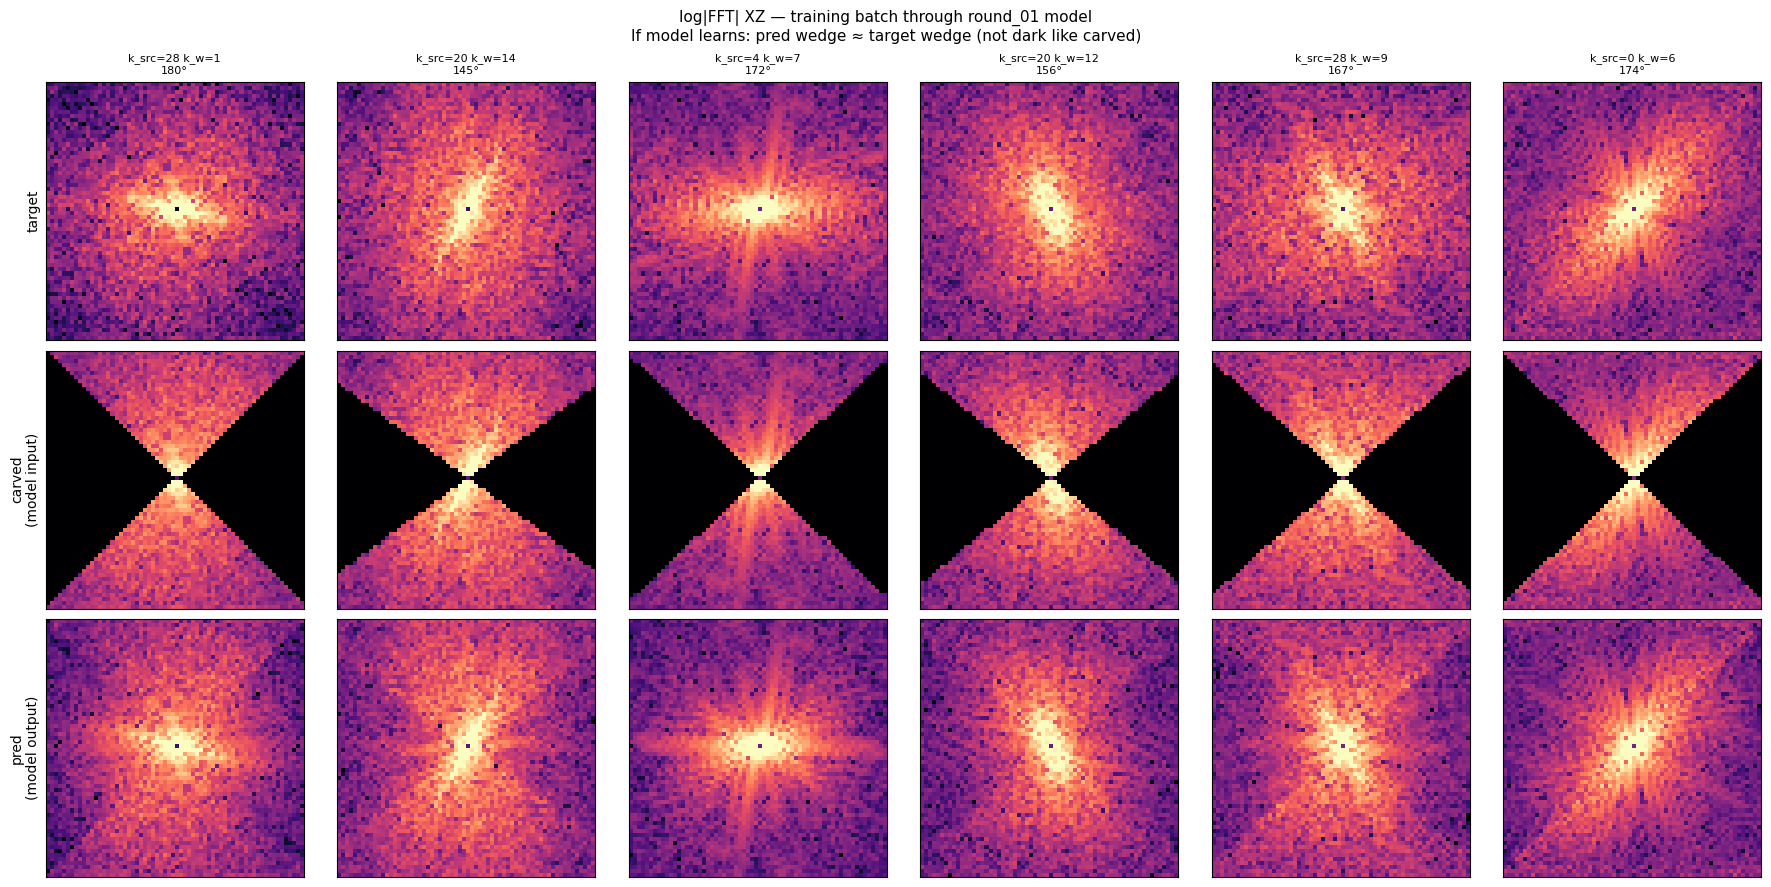


  sample     arc |  target_wedge  carved_wedge  pred_wedge  pred_filled?
---------------------------------------------------------------------------
       0  179.7° |        3.9956        0.0000      3.1831  ✓
       1  144.5° |        3.9188        0.0000      3.2210  ✓
       2  172.4° |        3.8449        0.0000      3.2060  ✓
       3  155.7° |        3.9639        0.0000      3.2169  ✓
       4  167.2° |        4.1763        0.0000      3.2466  ✓
       5  174.4° |        3.6041        0.0000      3.1153  ✓


In [13]:
if not MODEL_AVAILABLE:
    print('[SKIP]')
else:
    # ── Fourier XZ: target / carved / pred  (the key diagnostic) ─────────────
    keep_c = aug_dev.canonical_keep[k_wedge_t.to(device)].cpu().numpy()  # (B,C,C,C) shifted

    n_cols = BATCH
    fig, axes = plt.subplots(3, n_cols, figsize=(3 * n_cols, 9))

    for s in range(n_cols):
        ft_t = log_fft_xz(target_np[s])
        ft_c = log_fft_xz(carved_np[s])
        ft_p = log_fft_xz(pred_np[s])
        vmax = np.percentile(ft_t, 99) + 1e-9

        axes[0, s].imshow(ft_t.T, origin='lower', cmap='magma', vmax=vmax)
        axes[1, s].imshow(ft_c.T, origin='lower', cmap='magma', vmax=vmax)
        axes[2, s].imshow(ft_p.T, origin='lower', cmap='magma', vmax=vmax)

        axes[0, s].set_title(f'k_src={int(k_src_t[s])} k_w={int(k_wedge_t[s])}\n{arcs_t[s]:.0f}°', fontsize=8)
        for ax in axes[:, s]: ax.set_xticks([]); ax.set_yticks([])

    for r, lab in enumerate(['target', 'carved\n(model input)', 'pred\n(model output)']):
        axes[r, 0].set_ylabel(lab, fontsize=10)

    fig.suptitle('log|FFT| XZ — training batch through round_01 model\n'
                 'If model learns: pred wedge ≈ target wedge (not dark like carved)',
                 fontsize=11)
    plt.tight_layout(); plt.show()

    # ── Quantify: mean log-power in wedge region ──────────────────────────────
    print(f'\n{"sample":>8} {"arc":>7} | {"target_wedge":>13} {"carved_wedge":>13} {"pred_wedge":>11}  pred_filled?')
    print('-' * 75)
    for s in range(BATCH):
        miss = ~keep_c[s].astype(bool)                     # missing-wedge voxels (shifted)
        Ft = np.abs(np.fft.fftshift(np.fft.fftn(target_np[s])))[miss]
        Fc = np.abs(np.fft.fftshift(np.fft.fftn(carved_np[s])))[miss]
        Fp = np.abs(np.fft.fftshift(np.fft.fftn(pred_np[s])))[miss]
        t_mean = float(np.log1p(Ft).mean())
        c_mean = float(np.log1p(Fc).mean())
        p_mean = float(np.log1p(Fp).mean())
        # Is pred closer to target than carved is?
        filled = abs(p_mean - t_mean) < abs(c_mean - t_mean)
        mark = '✓' if filled else '✗'
        print(f'{s:>8} {arcs_t[s]:>6.1f}° | {t_mean:>13.4f} {c_mean:>13.4f} {p_mean:>11.4f}  {mark}')

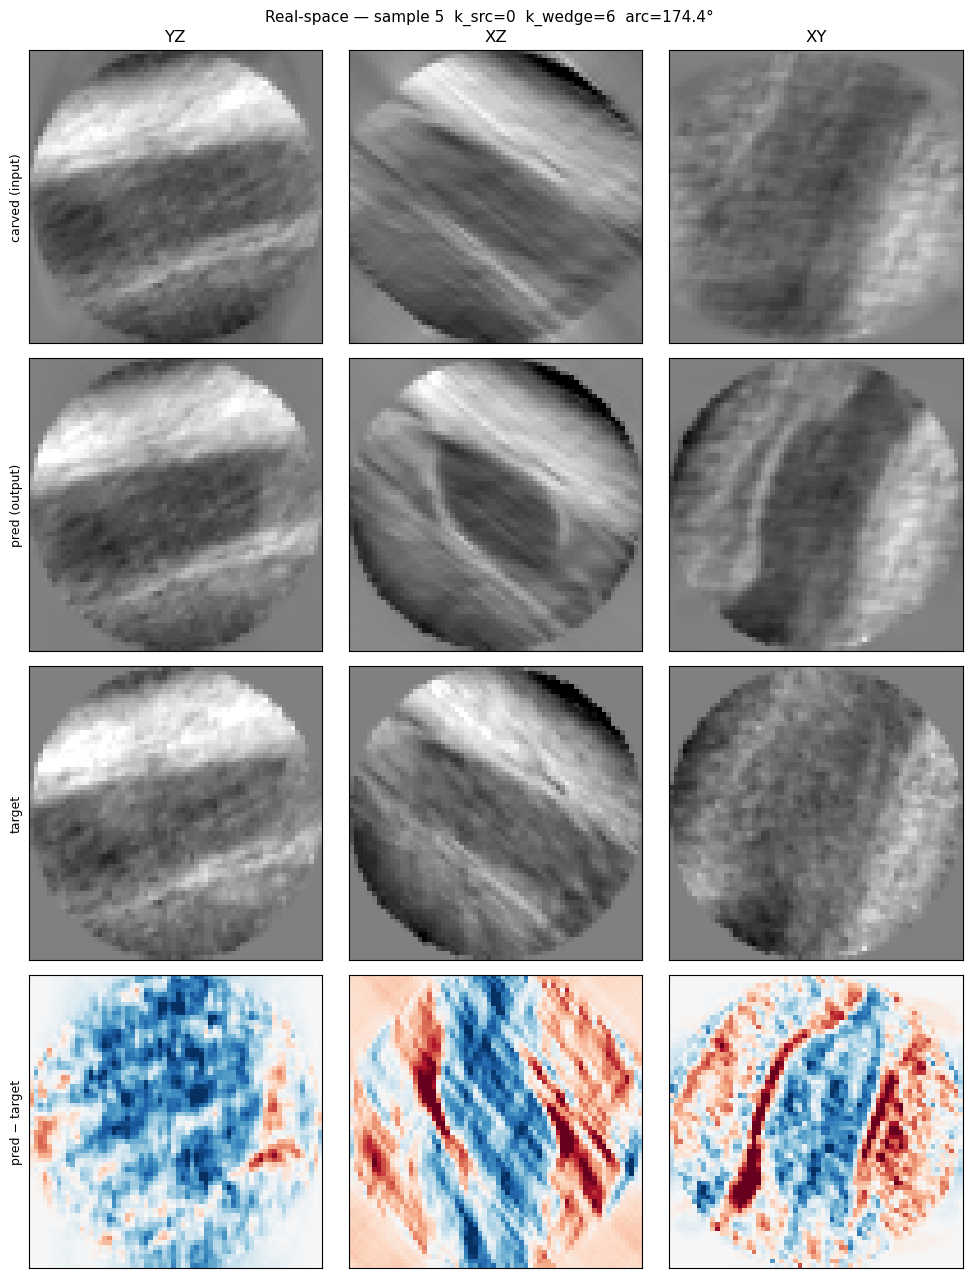


Interpretation guide:
  pred ≈ target             → model is learning the mapping ✓
  pred ≈ carved             → model predicts zeros at wedge (stuck) ✗
  pred ≠ carved, pred ≠ target → model is hallucinating ✗


In [14]:
if not MODEL_AVAILABLE:
    print('[SKIP]')
else:
    # ── Real-space: carved / pred / target / (pred − target) for one sample ──
    S = 5   # change to inspect other samples
    c_r = carved_np[S]; p_r = pred_np[S]; t_r = target_np[S]
    mid = CUBE // 2
    diff = p_r - t_r

    fig, axes = plt.subplots(4, 3, figsize=(10, 13))
    vlim = np.percentile(np.abs(t_r), 99) + 1e-9
    dlim = np.percentile(np.abs(diff), 99) + 1e-9
    plane_fns = [lambda a: a[mid], lambda a: a[:, mid], lambda a: a[:, :, mid]]
    plane_names = ['YZ', 'XZ', 'XY']

    for col, (name, sl) in enumerate(zip(plane_names, plane_fns)):
        axes[0, col].imshow(sl(c_r).T, origin='lower', cmap='gray', vmin=-vlim, vmax=vlim)
        axes[1, col].imshow(sl(p_r).T, origin='lower', cmap='gray', vmin=-vlim, vmax=vlim)
        axes[2, col].imshow(sl(t_r).T, origin='lower', cmap='gray', vmin=-vlim, vmax=vlim)
        axes[3, col].imshow(sl(diff).T, origin='lower', cmap='RdBu_r', vmin=-dlim, vmax=dlim)
        axes[0, col].set_title(name)

    for r, lab in enumerate(['carved (input)', 'pred (output)', 'target', 'pred − target']):
        axes[r, 0].set_ylabel(lab, fontsize=9)
    for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(f'Real-space — sample {S}  k_src={int(k_src_t[S])}  '
                 f'k_wedge={int(k_wedge_t[S])}  arc={arcs_t[S]:.1f}°', fontsize=11)
    plt.tight_layout(); plt.show()

    print('\nInterpretation guide:')
    print('  pred ≈ target             → model is learning the mapping ✓')
    print('  pred ≈ carved             → model predicts zeros at wedge (stuck) ✗')
    print('  pred ≠ carved, pred ≠ target → model is hallucinating ✗')